# Fase 5 — Multiclass disease classification pilot

Andiamo a capire se le FCGR contengono abbastanza informazxione per classificare individualmente  le sequenze di eccDNA.

A differenza del task Siamese che compara coppie di sequenze questo espetrimentousa una singola FCGR come input e predice direttamente la classe di malattia associata.

Questo esperimento è esplorativo e usa solo training e validation. Il test spilt non viene toccato.

Per il momento consideriamo 5 classi:

- healthy
- gastric cancer
- ovarian cancer
- prostate cancer
- colorectal cancer

La rappresentazione FCGR usa k=5 poichè nel confornto precedente era risultato essere il valore più promettente.

In [1]:
from pathlib import Path
import random
import time
import json

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


Caricamento metadata puliti

In [3]:
PROJECT_ROOT = Path("..")

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

METADATA_PATH = (
    PROCESSED_DIR
    / "eccdna_metadata_clean.tsv"
)

metadata = pd.read_csv(
    METADATA_PATH,
    sep="\t",
    low_memory=False
)

print(metadata.shape)
print(metadata.columns.tolist())

(3755079, 26)
['id', 'disease_binary_label', 'disease_binary_name', 'disease', 'chrom', 'start', 'end', 'length', 'gc', 'n_fraction', 'source_db', 'sample', 'tissue', 'cell_line', 'method', 'library_type', 'cluster_id', 'role', 'sequence_kind', 'sequence_fasta', 'sequence_body_id', 'sequence_circular_id', 'sequence_breakpoint_id', 'split_cluster', 'split_deepcircle_external', 'disease_clean']


In [4]:
CLASSES = [
    "healthy",
    "gastric cancer",
    "ovarian cancer",
    "prostate cancer",
    "colorectal cancer"
]

multiclass_df = metadata[
    metadata["disease_clean"].isin(
        CLASSES
    )
].copy()

multiclass_df[
    "disease_clean"
].value_counts()

disease_clean
gastric cancer       2593291
healthy               445138
ovarian cancer        172898
prostate cancer       170297
colorectal cancer      88639
Name: count, dtype: int64

Utilizzo di split_cluster

In [5]:
train_df = multiclass_df[
    multiclass_df["split_cluster"]
    == "train"
].copy()

val_df = multiclass_df[
    multiclass_df["split_cluster"]
    == "val"
].copy()

print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

Train: 2962487
Validation: 337216


In [6]:
print("\nTRAIN")
print(
    train_df[
        "disease_clean"
    ].value_counts()
)

print("\nVALIDATION")
print(
    val_df[
        "disease_clean"
    ].value_counts()
)


TRAIN
disease_clean
gastric cancer       2212052
healthy               381143
ovarian cancer        147776
prostate cancer       145810
colorectal cancer      75706
Name: count, dtype: int64

VALIDATION
disease_clean
gastric cancer       252571
healthy               43143
ovarian cancer        16767
prostate cancer       16224
colorectal cancer      8511
Name: count, dtype: int64


In [7]:
N_TRAIN_PER_CLASS = 10_000
N_VAL_PER_CLASS = 2_000

train_balanced = (
    train_df
    .groupby(
        "disease_clean",
        group_keys=False
    )
    .sample(
        n=N_TRAIN_PER_CLASS,
        random_state=SEED
    )
    .reset_index(drop=True)
)

val_balanced = (
    val_df
    .groupby(
        "disease_clean",
        group_keys=False
    )
    .sample(
        n=N_VAL_PER_CLASS,
        random_state=SEED
    )
    .reset_index(drop=True)
)

In [8]:
print(
    "TRAIN:",
    len(train_balanced)
)

print(
    train_balanced[
        "disease_clean"
    ].value_counts()
)

print(
    "\nVALIDATION:",
    len(val_balanced)
)

print(
    val_balanced[
        "disease_clean"
    ].value_counts()
)

TRAIN: 50000
disease_clean
colorectal cancer    10000
gastric cancer       10000
healthy              10000
ovarian cancer       10000
prostate cancer      10000
Name: count, dtype: int64

VALIDATION: 10000
disease_clean
colorectal cancer    2000
gastric cancer       2000
healthy              2000
ovarian cancer       2000
prostate cancer      2000
Name: count, dtype: int64


fcgr

In [9]:
K = 5

FCGR_CACHE_DIR = (
    PROCESSED_DIR
    / "fcgr_cache"
)

FCGR_PATH = (
    FCGR_CACHE_DIR
    / f"fcgr_k{K}.npy"
)

INDEX_PATH = (
    FCGR_CACHE_DIR
    / f"id_to_index_k{K}.json"
)

print("FCGR path exists:", FCGR_PATH.exists())
print("Index path exists:", INDEX_PATH.exists())

FCGR path exists: True
Index path exists: True


In [10]:
with open(
    INDEX_PATH,
    "r"
) as f:

    id_to_index = json.load(f)

fcgr_cache = np.load(
    FCGR_PATH,
    mmap_mode="r"
)

print(
    "Cache shape:",
    fcgr_cache.shape
)

print(
    "Cached IDs:",
    len(id_to_index)
)

Cache shape: (60739, 32, 32)
Cached IDs: 60739


In [11]:
train_ids = set(
    train_balanced["id"]
    .astype(str)
)

val_ids = set(
    val_balanced["id"]
    .astype(str)
)

pilot_ids = (
    train_ids
    | val_ids
)

print(
    "Pilot unique IDs:",
    len(pilot_ids)
)

Pilot unique IDs: 60000


In [12]:
cached_ids = set(
    id_to_index.keys()
)

missing_ids = (
    pilot_ids
    - cached_ids
)

print(
    "IDs already cached:",
    len(
        pilot_ids
        - missing_ids
    )
)

print(
    "Missing IDs:",
    len(missing_ids)
)

IDs already cached: 11669
Missing IDs: 48331


In [13]:
overlap = (
    train_ids
    & val_ids
)

print(
    "Train/val ID overlap:",
    len(overlap)
)

Train/val ID overlap: 0


## FCGR cache for multiclass pilot

La cache FCGR precedentemente creata per l'esperiemnto Siamese contiene solo un suset delle seuquenze selezionate per il ulticlass pilot.7

Creaiamo quindi una cache seprata per le sequenze usate in questo esperimento. In modo da evvitare di nmodificare la cache usata nell'esperimento precdente e mantenre così separate le due pipeline.

In [14]:
MULTICLASS_CACHE_DIR = (
    PROCESSED_DIR
    / "fcgr_cache_multiclass"
)

MULTICLASS_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MC_FCGR_PATH = (
    MULTICLASS_CACHE_DIR
    / f"fcgr_multiclass_k{K}.npy"
)

MC_INDEX_PATH = (
    MULTICLASS_CACHE_DIR
    / f"id_to_index_multiclass_k{K}.json"
)

print(MC_FCGR_PATH)
print(MC_INDEX_PATH)

..\data\processed\fcgr_cache_multiclass\fcgr_multiclass_k5.npy
..\data\processed\fcgr_cache_multiclass\id_to_index_multiclass_k5.json


In [15]:
RAW_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

FASTA_PATH = (
    RAW_DIR
    / "eccdna_disease_detection.body.fa"
)

In [16]:
def load_fasta_sequences(
    fasta_path,
    target_ids
):

    target_ids = set(
        map(str, target_ids)
    )

    sequences = {}

    current_id = None
    current_sequence = []

    with open(
        fasta_path,
        "r"
    ) as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):

                if (
                    current_id is not None
                    and current_id in target_ids
                ):

                    sequences[
                        current_id
                    ] = "".join(
                        current_sequence
                    )

                    if (
                        len(sequences)
                        == len(target_ids)
                    ):
                        break

                header = line[1:]

                current_id = (
                    header
                    .split("|", 1)[0]
                    .strip()
                )

                current_sequence = []

            else:

                if current_id in target_ids:

                    current_sequence.append(
                        line
                    )

        if (
            current_id is not None
            and current_id in target_ids
            and current_id not in sequences
        ):

            sequences[
                current_id
            ] = "".join(
                current_sequence
            )

    return sequences

In [17]:
def compute_fcgr(
    sequence,
    k
):

    sequence = sequence.upper()

    size = 2 ** k

    fcgr_counts = np.zeros(
        (size, size),
        dtype=np.int32
    )

    corners = {
        "A": (0.0, 1.0),
        "C": (0.0, 0.0),
        "G": (1.0, 0.0),
        "T": (1.0, 1.0)
    }

    for i in range(
        len(sequence) - k + 1
    ):

        kmer = sequence[
            i:i+k
        ]

        if any(
            base not in corners
            for base in kmer
        ):
            continue

        x = 0.5
        y = 0.5

        for base in kmer:

            cx, cy = corners[
                base
            ]

            x = (
                x + cx
            ) * 0.5

            y = (
                y + cy
            ) * 0.5

        col = min(
            int(
                x * size
            ),
            size - 1
        )

        row = min(
            int(
                y * size
            ),
            size - 1
        )

        fcgr_counts[
            row,
            col
        ] += 1

    return fcgr_counts

In [18]:
def normalize_fcgr(
    fcgr_counts
):

    total = fcgr_counts.sum()

    if total == 0:

        return (
            fcgr_counts
            .astype(
                np.float32
            )
        )

    return (
        fcgr_counts
        .astype(
            np.float32
        )
        / total
    )

In [19]:
MC_CACHE_EXISTS = (
    MC_FCGR_PATH.exists()
    and MC_INDEX_PATH.exists()
)

print(
    "Multiclass cache exists:",
    MC_CACHE_EXISTS
)

Multiclass cache exists: True


In [20]:
if MC_CACHE_EXISTS:

    print(
        "Multiclass FCGR cache "
        "already available."
    )

    with open(
        MC_INDEX_PATH,
        "r"
    ) as f:

        mc_id_to_index = (
            json.load(f)
        )

    mc_fcgr_cache = np.load(
        MC_FCGR_PATH,
        mmap_mode="r"
    )

else:

    print(
        "Creating multiclass "
        "FCGR cache..."
    )

    pilot_ids_sorted = sorted(
        pilot_ids
    )

    mc_id_to_index = {
        seq_id: idx
        for idx, seq_id
        in enumerate(
            pilot_ids_sorted
        )
    }

    sequences = (
        load_fasta_sequences(
            FASTA_PATH,
            pilot_ids_sorted
        )
    )

    print(
        "Requested:",
        len(
            pilot_ids_sorted
        )
    )

    print(
        "Loaded:",
        len(sequences)
    )

    if (
        len(sequences)
        != len(
            pilot_ids_sorted
        )
    ):

        raise RuntimeError(
            "Some sequences are missing."
        )

    with open(
        MC_INDEX_PATH,
        "w"
    ) as f:

        json.dump(
            mc_id_to_index,
            f
        )

    size = 2 ** K

    fcgr_memmap = (
        np.lib.format.open_memmap(
            MC_FCGR_PATH,
            mode="w+",
            dtype=np.float32,
            shape=(
                len(
                    pilot_ids_sorted
                ),
                size,
                size
            )
        )
    )

    start = time.time()

    for i, seq_id in enumerate(
        pilot_ids_sorted
    ):

        counts = compute_fcgr(
            sequences[
                seq_id
            ],
            K
        )

        fcgr = normalize_fcgr(
            counts
        )

        fcgr_memmap[
            mc_id_to_index[
                seq_id
            ]
        ] = fcgr

        if (
            (i + 1) % 5000 == 0
            or i == 0
        ):

            elapsed = (
                time.time()
                - start
            )

            print(
                f"{i+1:,}/"
                f"{len(pilot_ids_sorted):,}"
                f" | "
                f"{elapsed/60:.1f} min"
            )

    fcgr_memmap.flush()

    del fcgr_memmap

    mc_fcgr_cache = np.load(
        MC_FCGR_PATH,
        mmap_mode="r"
    )

    print(
        "Multiclass FCGR "
        "cache completed."
    )

Multiclass FCGR cache already available.


In [21]:
print(
    "Cache shape:",
    mc_fcgr_cache.shape
)

print(
    "Cache dtype:",
    mc_fcgr_cache.dtype
)

print(
    "Indexed IDs:",
    len(
        mc_id_to_index
    )
)

Cache shape: (60000, 32, 32)
Cache dtype: float32
Indexed IDs: 60000


Mappatura classi

In [22]:
CLASS_TO_IDX = {
    class_name: idx
    for idx, class_name
    in enumerate(CLASSES)
}

IDX_TO_CLASS = {
    idx: class_name
    for class_name, idx
    in CLASS_TO_IDX.items()
}

print(CLASS_TO_IDX)

{'healthy': 0, 'gastric cancer': 1, 'ovarian cancer': 2, 'prostate cancer': 3, 'colorectal cancer': 4}


In [23]:
train_balanced["label"] = (
    train_balanced[
        "disease_clean"
    ]
    .map(CLASS_TO_IDX)
)

val_balanced["label"] = (
    val_balanced[
        "disease_clean"
    ]
    .map(CLASS_TO_IDX)
)

print(
    train_balanced[
        ["disease_clean", "label"]
    ]
    .drop_duplicates()
    .sort_values("label")
)

           disease_clean  label
20000            healthy      0
10000     gastric cancer      1
30000     ovarian cancer      2
40000    prostate cancer      3
0      colorectal cancer      4


Dataset pythorch multiclass

In [24]:
class MulticlassFCGRDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        fcgr_path,
        id_to_index
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.fcgr_path = fcgr_path

        self.id_to_index = (
            id_to_index
        )

        self.fcgr_cache = None


    def _open_cache(self):

        if self.fcgr_cache is None:

            self.fcgr_cache = np.load(
                self.fcgr_path,
                mmap_mode="r"
            )


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        idx
    ):

        self._open_cache()

        row = self.dataframe.iloc[
            idx
        ]

        seq_id = str(
            row["id"]
        )

        fcgr_idx = (
            self.id_to_index[
                seq_id
            ]
        )

        fcgr = np.array(
            self.fcgr_cache[
                fcgr_idx
            ],
            dtype=np.float32,
            copy=True
        )

        # H x W -> 1 x H x W
        fcgr = torch.from_numpy(
            fcgr
        ).unsqueeze(0)

        label = torch.tensor(
            int(
                row["label"]
            ),
            dtype=torch.long
        )

        return (
            fcgr,
            label
        )

In [25]:
train_dataset = MulticlassFCGRDataset(
    train_balanced,
    MC_FCGR_PATH,
    mc_id_to_index
)

val_dataset = MulticlassFCGRDataset(
    val_balanced,
    MC_FCGR_PATH,
    mc_id_to_index
)

print(
    "Train dataset:",
    len(train_dataset)
)

print(
    "Validation dataset:",
    len(val_dataset)
)

Train dataset: 50000
Validation dataset: 10000


In [26]:
x, y = train_dataset[0]

print(
    "FCGR shape:",
    x.shape
)

print(
    "Label:",
    y.item()
)

print(
    "Class:",
    IDX_TO_CLASS[
        y.item()
    ]
)

FCGR shape: torch.Size([1, 32, 32])
Label: 4
Class: colorectal cancer


Dataloader

In [27]:
BATCH_SIZE = 256
NUM_WORKERS = 0

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [29]:
# smoke test

x_batch, y_batch = next(
    iter(train_loader)
)

print(
    "X:",
    x_batch.shape
)

print(
    "y:",
    y_batch.shape
)

print(
    "labels:",
    torch.unique(
        y_batch
    )
)

X: torch.Size([256, 1, 32, 32])
y: torch.Size([256])
labels: tensor([0, 1, 2, 3, 4])


CNN Multiclass

In [30]:
class MulticlassFCGRCNN(
    nn.Module
):

    def __init__(
        self,
        num_classes=5
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [31]:
model = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

print(model)

MulticlassFCGRCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4)

In [32]:
n_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {n_params:,}"
)

print(
    "Device:",
    next(
        model.parameters()
    ).device
)

Parameters: 101,701
Device: cuda:0


Loss e Optimizer

In [33]:
criterion = nn.CrossEntropyLoss()

In [34]:
# optimizer

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [35]:
# mixed precision

USE_AMP = (
    DEVICE.type == "cuda"
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

In [36]:
# smoke test gpu

x_batch = x_batch.to(
    DEVICE,
    non_blocking=True
)

y_batch = y_batch.to(
    DEVICE,
    non_blocking=True
)

with torch.no_grad():

    logits = model(
        x_batch
    )

print(
    "Logits shape:",
    logits.shape
)

print(
    "Expected:",
    (
        BATCH_SIZE,
        len(CLASSES)
    )
)

Logits shape: torch.Size([256, 5])
Expected: (256, 5)


Train

In [37]:
def train_one_epoch_multiclass(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    use_amp
):

    model.train()

    total_loss = 0.0

    all_true = []
    all_pred = []

    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=use_amp
        ):

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        total_loss += (
            loss.item()
            * x.size(0)
        )

        preds = torch.argmax(
            logits,
            dim=1
        )

        all_true.extend(
            y.detach()
            .cpu()
            .numpy()
        )

        all_pred.extend(
            preds.detach()
            .cpu()
            .numpy()
        )

    loss_mean = (
        total_loss
        / len(loader.dataset)
    )

    macro_f1 = f1_score(
        all_true,
        all_pred,
        average="macro"
    )

    balanced_acc = (
        balanced_accuracy_score(
            all_true,
            all_pred
        )
    )

    accuracy = accuracy_score(
        all_true,
        all_pred
    )

    return {
        "loss": loss_mean,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc
    }

Validation

In [38]:
def evaluate_multiclass(
    model,
    loader,
    criterion,
    device,
    use_amp
):

    model.eval()

    total_loss = 0.0

    all_true = []
    all_pred = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=use_amp
            ):

                logits = model(x)

                loss = criterion(
                    logits,
                    y
                )

            total_loss += (
                loss.item()
                * x.size(0)
            )

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_true.extend(
                y.cpu().numpy()
            )

            all_pred.extend(
                preds.cpu().numpy()
            )

    loss_mean = (
        total_loss
        / len(loader.dataset)
    )

    return {
        "loss": loss_mean,

        "accuracy": accuracy_score(
            all_true,
            all_pred
        ),

        "macro_f1": f1_score(
            all_true,
            all_pred,
            average="macro"
        ),

        "balanced_accuracy":
            balanced_accuracy_score(
                all_true,
                all_pred
            ),

        "y_true": np.array(
            all_true
        ),

        "y_pred": np.array(
            all_pred
        )
    }

test con solo 3 epoche

In [39]:
PILOT_EPOCHS = 3

pilot_history = []

for epoch in range(
    1,
    PILOT_EPOCHS + 1
):

    start = time.time()

    train_metrics = (
        train_one_epoch_multiclass(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler,
            DEVICE,
            USE_AMP
        )
    )

    val_metrics = (
        evaluate_multiclass(
            model,
            val_loader,
            criterion,
            DEVICE,
            USE_AMP
        )
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = (
        time.time()
        - start
    )

    pilot_history.append({
        "epoch": epoch,

        "train_loss":
            train_metrics[
                "loss"
            ],

        "train_accuracy":
            train_metrics[
                "accuracy"
            ],

        "train_macro_f1":
            train_metrics[
                "macro_f1"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train loss "
        f"{train_metrics['loss']:.4f} | "
        f"train F1 "
        f"{train_metrics['macro_f1']:.4f} | "
        f"val loss "
        f"{val_metrics['loss']:.4f} | "
        f"val F1 "
        f"{val_metrics['macro_f1']:.4f} | "
        f"val bal acc "
        f"{val_metrics['balanced_accuracy']:.4f}"
    )

Epoch 01 | 8.8s | train loss 1.2444 | train F1 0.4610 | val loss 4.0733 | val F1 0.0732 | val bal acc 0.2032
Epoch 02 | 9.7s | train loss 1.1751 | train F1 0.4893 | val loss 5.8044 | val F1 0.0726 | val bal acc 0.2029
Epoch 03 | 10.8s | train loss 1.1567 | train F1 0.4942 | val loss 3.8868 | val F1 0.0968 | val bal acc 0.2156


In [40]:
pilot_history_df = pd.DataFrame(
    pilot_history
)

pilot_history_df

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,val_balanced_accuracy
0,1,1.244439,0.47618,0.461050,4.073262,0.2032,0.073152,0.2032
1,2,1.175077,0.50940,0.489257,5.804429,0.2029,0.072551,0.2029
2,3,1.156724,0.51664,0.494173,3.886755,0.2156,0.096810,0.2156


In [41]:
print(
    classification_report(
        val_metrics["y_true"],
        val_metrics["y_pred"],
        target_names=[
            IDX_TO_CLASS[i]
            for i in range(
                len(CLASSES)
            )
        ],
        digits=4
    )
)

                   precision    recall  f1-score   support

          healthy     0.7594    0.0805    0.1456      2000
   gastric cancer     0.0000    0.0000    0.0000      2000
   ovarian cancer     0.2038    0.9975    0.3385      2000
  prostate cancer     0.0000    0.0000    0.0000      2000
colorectal cancer     0.0000    0.0000    0.0000      2000

         accuracy                         0.2156     10000
        macro avg     0.1927    0.2156    0.0968     10000
     weighted avg     0.1927    0.2156    0.0968     10000



c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Confusion matrix

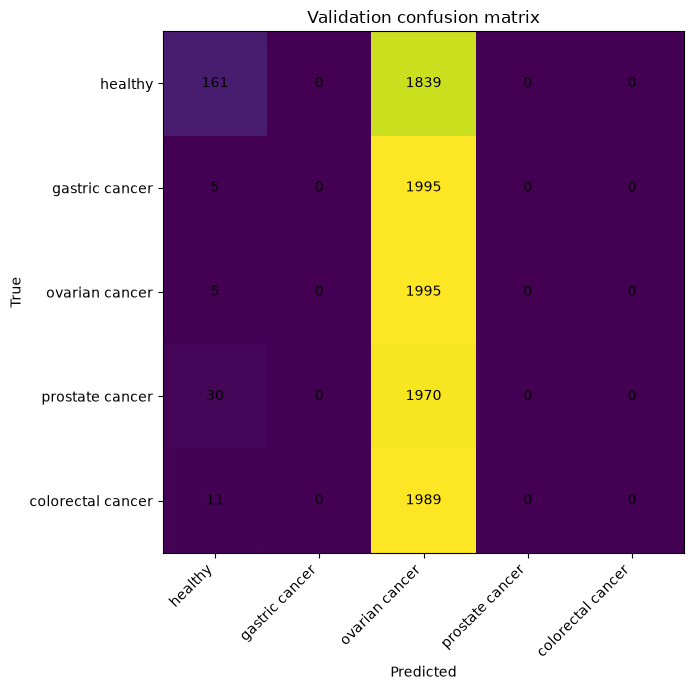

In [42]:
cm = confusion_matrix(
    val_metrics["y_true"],
    val_metrics["y_pred"]
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

im = ax.imshow(cm)

ax.set_xticks(
    range(len(CLASSES))
)

ax.set_yticks(
    range(len(CLASSES))
)

ax.set_xticklabels(
    [
        IDX_TO_CLASS[i]
        for i in range(len(CLASSES))
    ],
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    [
        IDX_TO_CLASS[i]
        for i in range(len(CLASSES))
    ]
)

ax.set_xlabel(
    "Predicted"
)

ax.set_ylabel(
    "True"
)

ax.set_title(
    "Validation confusion matrix"
)

for i in range(
    cm.shape[0]
):
    for j in range(
        cm.shape[1]
    ):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Diagnosi train vs validation

In [43]:
diagnostic_cols = [
    "disease_clean",
    "split_cluster",
    "length",
    "gc_content",
    "source_db",
    "tissue"
]

[
    col
    for col in diagnostic_cols
    if col in multiclass_df.columns
]

['disease_clean', 'split_cluster', 'length', 'source_db', 'tissue']

In [44]:
source_distribution = (
    multiclass_df
    .groupby([
        "split_cluster",
        "disease_clean",
        "source_db"
    ])
    .size()
    .reset_index(name="count")
)

source_distribution

,split_cluster,disease_clean,source_db,count
0,test,colorectal cancer,CircleBaseV2,4363
1,test,colorectal cancer,eccDNABase,59
2,test,gastric cancer,CircleBaseV2,127279
3,test,gastric cancer,eccDNABase,1389
4,test,healthy,CircleBaseV2,10299
5,test,healthy,eccDNABase,10553
6,test,ovarian cancer,CircleBaseV2,17
7,test,ovarian cancer,eccDNABase,8338
8,test,prostate cancer,CircleBaseV2,710
9,test,prostate cancer,eccDNABase,7553


In [45]:
source_distribution["percentage"] = (
    source_distribution
    .groupby([
        "split_cluster",
        "disease_clean"
    ])["count"]
    .transform(
        lambda x: 100 * x / x.sum()
    )
)

source_distribution

,split_cluster,disease_clean,source_db,count,percentage
0,test,colorectal cancer,CircleBaseV2,4363,98.665762
1,test,colorectal cancer,eccDNABase,59,1.334238
2,test,gastric cancer,CircleBaseV2,127279,98.920478
3,test,gastric cancer,eccDNABase,1389,1.079522
4,test,healthy,CircleBaseV2,10299,49.390946
5,test,healthy,eccDNABase,10553,50.609054
6,test,ovarian cancer,CircleBaseV2,17,0.203471
7,test,ovarian cancer,eccDNABase,8338,99.796529
8,test,prostate cancer,CircleBaseV2,710,8.592521
9,test,prostate cancer,eccDNABase,7553,91.407479


In [46]:
tissue_distribution = (
    multiclass_df
    .groupby([
        "split_cluster",
        "disease_clean",
        "tissue"
    ])
    .size()
    .reset_index(name="count")
)

tissue_distribution["percentage"] = (
    tissue_distribution
    .groupby([
        "split_cluster",
        "disease_clean"
    ])["count"]
    .transform(
        lambda x: 100 * x / x.sum()
    )
)

tissue_distribution

,split_cluster,disease_clean,tissue,count,percentage
0,test,colorectal cancer,COLO320DM,1,0.022614
1,test,colorectal cancer,Colon,58,1.311624
2,test,colorectal cancer,Colorectal tumor tissue,4363,98.665762
3,test,gastric cancer,Stomach,128668,100.000000
4,test,healthy,Brain,13,0.066554
...,...,...,...,...,...
414,val,prostate cancer,Lncap,122,0.766428
415,val,prostate cancer,PC-3,1408,8.845332
416,val,prostate cancer,PC3,3,0.018847
417,val,prostate cancer,Prostate,1705,10.711145


In [47]:
length_stats = (
    multiclass_df
    .groupby([
        "split_cluster",
        "disease_clean"
    ])["length"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

length_stats

count         mean  median           std  \
split_cluster disease_clean                                                   
test          colorectal cancer     4422   913.891000   730.0   1398.488567   
              gastric cancer      128668  1011.412084   769.0   1129.647376   
              healthy              20852  5370.350470   372.0  18716.288578   
              ovarian cancer        8355   368.937403   247.0   2721.899262   
              prostate cancer       8263   681.497640   327.0   4488.054920   
train         colorectal cancer    75706   933.497688   730.0   2470.718552   
              gastric cancer     2212052  1016.226935   768.0   1521.769708   
              healthy             381143  5310.166043   370.0  18564.339670   
              ovarian cancer      147776   393.455933   248.0   2921.651883   
              prostate cancer     145810   635.039421   326.0   3291.102041   
val           colorectal cancer     8511   894.178240   726.0   1229.273615   
              gastric cancer      252571  1015.601245   768.0   1447.454983   
              healthy              43143  5181.354426   363.0  17963.403848   
              ovarian cancer       16767   393.757977   247.0   3262.084108   
              prostate cancer      16224   609.060959   326.0   2769.590989   

                                 min     max  
split_cluster disease_clean                   
test          colorectal cancer   94   83000  
              gastric cancer      50  146998  
              healthy             50  199267  
              ovarian cancer      61  154799  
              prostate cancer     57  198576  
train         colorectal cancer   78  197582  
              gastric cancer      50  199832  
              healthy             50  199873  
              ovarian cancer      55  193263  
              prostate cancer     50  199998  
val           colorectal cancer   77   97707  
              gastric cancer      50  188536  
              healthy             50  198846  
              ovarian cancer      57  198047  
              prostate cancer     50  155551

In [48]:
length_quantiles = (
    multiclass_df
    .groupby([
        "split_cluster",
        "disease_clean"
    ])["length"]
    .quantile([
        0.10,
        0.25,
        0.50,
        0.75,
        0.90
    ])
    .unstack()
)

length_quantiles

0.10   0.25   0.50    0.75    0.90
split_cluster disease_clean                                         
test          colorectal cancer  374.0  524.0  730.0  1054.0  1581.9
              gastric cancer     372.0  549.0  769.0  1166.0  1835.0
              healthy            117.0  181.0  372.0  2251.0  8650.4
              ovarian cancer     126.0  163.0  247.0   343.0   537.0
              prostate cancer    151.0  207.5  327.0   545.0   992.0
train         colorectal cancer  373.0  518.0  730.0  1066.0  1564.0
              gastric cancer     372.0  548.0  768.0  1164.0  1832.0
              healthy            116.0  177.0  370.0  2118.0  8424.8
              ovarian cancer     128.0  165.0  248.0   343.0   543.0
              prostate cancer    150.0  208.0  326.0   540.0   990.0
val           colorectal cancer  372.0  508.0  726.0  1053.5  1544.0
              gastric cancer     372.0  548.0  768.0  1166.0  1838.0
              healthy            115.0  176.0  363.0  2086.0  8498.0
              ovarian cancer     128.0  165.0  247.0   344.0   543.0
              prostate cancer    150.0  211.0  326.0   532.0   962.0

Esperimento: random split diagnostico

In [49]:
from sklearn.model_selection import train_test_split

diagnostic_df = pd.concat(
    [
        train_balanced,
        val_balanced
    ],
    ignore_index=True
)

print(diagnostic_df.shape)

print(
    diagnostic_df[
        "disease_clean"
    ].value_counts()
)

(60000, 27)
disease_clean
colorectal cancer    12000
gastric cancer       12000
healthy              12000
ovarian cancer       12000
prostate cancer      12000
Name: count, dtype: int64


In [50]:
random_train_df, random_val_df = (
    train_test_split(
        diagnostic_df,
        test_size=0.20,
        random_state=SEED,
        stratify=diagnostic_df["label"]
    )
)

random_train_df = (
    random_train_df
    .reset_index(drop=True)
)

random_val_df = (
    random_val_df
    .reset_index(drop=True)
)

print(
    "Random train:",
    len(random_train_df)
)

print(
    random_train_df[
        "disease_clean"
    ].value_counts()
)

print(
    "\nRandom val:",
    len(random_val_df)
)

print(
    random_val_df[
        "disease_clean"
    ].value_counts()
)

Random train: 48000
disease_clean
gastric cancer       9600
healthy              9600
colorectal cancer    9600
prostate cancer      9600
ovarian cancer       9600
Name: count, dtype: int64

Random val: 12000
disease_clean
prostate cancer      2400
ovarian cancer       2400
healthy              2400
colorectal cancer    2400
gastric cancer       2400
Name: count, dtype: int64


In [51]:
random_train_dataset = MulticlassFCGRDataset(
    random_train_df,
    MC_FCGR_PATH,
    mc_id_to_index
)

random_val_dataset = MulticlassFCGRDataset(
    random_val_df,
    MC_FCGR_PATH,
    mc_id_to_index
)

random_train_loader = DataLoader(
    random_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

random_val_loader = DataLoader(
    random_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [52]:
# modello nuovo

random_model = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

random_criterion = nn.CrossEntropyLoss()

random_optimizer = torch.optim.AdamW(
    random_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

random_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

In [53]:
RANDOM_PILOT_EPOCHS = 3

random_history = []

for epoch in range(
    1,
    RANDOM_PILOT_EPOCHS + 1
):

    start = time.time()

    train_metrics_random = (
        train_one_epoch_multiclass(
            random_model,
            random_train_loader,
            random_criterion,
            random_optimizer,
            random_scaler,
            DEVICE,
            USE_AMP
        )
    )

    val_metrics_random = (
        evaluate_multiclass(
            random_model,
            random_val_loader,
            random_criterion,
            DEVICE,
            USE_AMP
        )
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    random_history.append({
        "epoch": epoch,
        "train_loss":
            train_metrics_random["loss"],
        "train_macro_f1":
            train_metrics_random["macro_f1"],
        "val_loss":
            val_metrics_random["loss"],
        "val_macro_f1":
            val_metrics_random["macro_f1"],
        "val_balanced_accuracy":
            val_metrics_random[
                "balanced_accuracy"
            ]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train F1 "
        f"{train_metrics_random['macro_f1']:.4f} | "
        f"val F1 "
        f"{val_metrics_random['macro_f1']:.4f} | "
        f"val bal acc "
        f"{val_metrics_random['balanced_accuracy']:.4f}"
    )

Epoch 01 | 9.5s | train F1 0.4529 | val F1 0.3434 | val bal acc 0.3885
Epoch 02 | 9.8s | train F1 0.4863 | val F1 0.2200 | val bal acc 0.3332
Epoch 03 | 9.7s | train F1 0.4930 | val F1 0.0668 | val bal acc 0.2000


In [54]:
stable_model = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

stable_criterion = nn.CrossEntropyLoss()

stable_optimizer = torch.optim.AdamW(
    stable_model.parameters(),
    lr=1e-4,          # 10 volte più basso
    weight_decay=1e-4
)

stable_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

In [55]:
STABLE_EPOCHS = 8

best_val_f1 = -np.inf
best_epoch = None

stable_history = []

for epoch in range(1, STABLE_EPOCHS + 1):

    start = time.time()

    train_metrics = train_one_epoch_multiclass(
        stable_model,
        random_train_loader,
        stable_criterion,
        stable_optimizer,
        stable_scaler,
        DEVICE,
        USE_AMP
    )

    val_metrics = evaluate_multiclass(
        stable_model,
        random_val_loader,
        stable_criterion,
        DEVICE,
        USE_AMP
    )

    elapsed = time.time() - start

    stable_history.append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"]
    })

    if val_metrics["macro_f1"] > best_val_f1:

        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch

        torch.save(
            stable_model.state_dict(),
            "multiclass_random_lr1e4_best.pt"
        )

        best_msg = " <-- BEST"

    else:
        best_msg = ""

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train F1 {train_metrics['macro_f1']:.4f} | "
        f"val F1 {val_metrics['macro_f1']:.4f} | "
        f"val bal acc {val_metrics['balanced_accuracy']:.4f}"
        f"{best_msg}"
    )

print(
    f"\nBest epoch: {best_epoch} | "
    f"Best val macro F1: {best_val_f1:.4f}"
)

Epoch 01 | 9.6s | train F1 0.3768 | val F1 0.4529 | val bal acc 0.4553 <-- BEST
Epoch 02 | 9.6s | train F1 0.4705 | val F1 0.4538 | val bal acc 0.4714 <-- BEST
Epoch 03 | 10.1s | train F1 0.4815 | val F1 0.4501 | val bal acc 0.4800
Epoch 04 | 9.8s | train F1 0.4857 | val F1 0.4633 | val bal acc 0.4868 <-- BEST
Epoch 05 | 10.0s | train F1 0.4882 | val F1 0.3077 | val bal acc 0.3387
Epoch 06 | 9.8s | train F1 0.4940 | val F1 0.3781 | val bal acc 0.4137
Epoch 07 | 10.0s | train F1 0.4967 | val F1 0.2883 | val bal acc 0.3685
Epoch 08 | 9.9s | train F1 0.4977 | val F1 0.4827 | val bal acc 0.4961 <-- BEST

Best epoch: 8 | Best val macro F1: 0.4827


## Cluster-aware training with lower learning rate

Il precedente random split mostra che riducendo il learning rate a 1e-4 viene migliorata la stabilità del training.

La stessa configurazione viene ora usata per valuatre l'orginale split cluster-aware isolando l'effetto dello split senza cambiare altro.

In [56]:
cluster_model = MulticlassFCGRCNN(
    num_classes=len(CLASSES)
).to(DEVICE)

cluster_criterion = nn.CrossEntropyLoss()

cluster_optimizer = torch.optim.AdamW(
    cluster_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

cluster_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print(
    "Model device:",
    next(cluster_model.parameters()).device
)

Model device: cuda:0


In [57]:
CLUSTER_EPOCHS = 8

cluster_history = []

best_cluster_f1 = -np.inf
best_cluster_epoch = None

CLUSTER_CHECKPOINT = (
    "multiclass_cluster_lr1e4_best.pt"
)

for epoch in range(
    1,
    CLUSTER_EPOCHS + 1
):

    start = time.time()

    train_metrics_cluster = (
        train_one_epoch_multiclass(
            cluster_model,
            train_loader,
            cluster_criterion,
            cluster_optimizer,
            cluster_scaler,
            DEVICE,
            USE_AMP
        )
    )

    val_metrics_cluster = (
        evaluate_multiclass(
            cluster_model,
            val_loader,
            cluster_criterion,
            DEVICE,
            USE_AMP
        )
    )

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start

    cluster_history.append({
        "epoch": epoch,
        "train_loss":
            train_metrics_cluster["loss"],
        "train_macro_f1":
            train_metrics_cluster["macro_f1"],
        "val_loss":
            val_metrics_cluster["loss"],
        "val_macro_f1":
            val_metrics_cluster["macro_f1"],
        "val_balanced_accuracy":
            val_metrics_cluster[
                "balanced_accuracy"
            ]
    })

    if (
        val_metrics_cluster["macro_f1"]
        > best_cluster_f1
    ):

        best_cluster_f1 = (
            val_metrics_cluster[
                "macro_f1"
            ]
        )

        best_cluster_epoch = epoch

        torch.save(
            cluster_model.state_dict(),
            CLUSTER_CHECKPOINT
        )

        best_msg = " <-- BEST"

    else:
        best_msg = ""

    print(
        f"Epoch {epoch:02d} | "
        f"{elapsed:.1f}s | "
        f"train F1 "
        f"{train_metrics_cluster['macro_f1']:.4f} | "
        f"val F1 "
        f"{val_metrics_cluster['macro_f1']:.4f} | "
        f"val bal acc "
        f"{val_metrics_cluster['balanced_accuracy']:.4f}"
        f"{best_msg}"
    )

print(
    f"\nBest epoch: {best_cluster_epoch} | "
    f"Best val macro F1: "
    f"{best_cluster_f1:.4f}"
)

Epoch 01 | 10.5s | train F1 0.3991 | val F1 0.4636 | val bal acc 0.4831 <-- BEST
Epoch 02 | 10.2s | train F1 0.4710 | val F1 0.4303 | val bal acc 0.4691
Epoch 03 | 10.4s | train F1 0.4786 | val F1 0.4158 | val bal acc 0.4463
Epoch 04 | 10.2s | train F1 0.4874 | val F1 0.4858 | val bal acc 0.4995 <-- BEST
Epoch 05 | 10.3s | train F1 0.4902 | val F1 0.4812 | val bal acc 0.4986
Epoch 06 | 10.4s | train F1 0.4888 | val F1 0.4762 | val bal acc 0.5065
Epoch 07 | 10.3s | train F1 0.4964 | val F1 0.4463 | val bal acc 0.4844
Epoch 08 | 10.5s | train F1 0.4953 | val F1 0.4164 | val bal acc 0.4374

Best epoch: 4 | Best val macro F1: 0.4858


In [58]:
cluster_history_df = pd.DataFrame(
    cluster_history
)

cluster_history_df

,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_balanced_accuracy
0,1,1.390961,0.399087,1.284384,0.463592,0.4831
1,2,1.240160,0.471031,1.248744,0.430345,0.4691
2,3,1.205229,0.478567,1.329760,0.415783,0.4463
3,4,1.190363,0.487379,1.183949,0.485801,0.4995
4,5,1.179509,0.490199,1.187668,0.481202,0.4986
5,6,1.174612,0.488790,1.175297,0.476165,0.5065
6,7,1.166603,0.496436,1.232078,0.446319,0.4844
7,8,1.163816,0.495345,1.401109,0.416351,0.4374


In [59]:
cluster_model.load_state_dict(
    torch.load(
        CLUSTER_CHECKPOINT,
        map_location=DEVICE
    )
)

best_cluster_metrics = evaluate_multiclass(
    cluster_model,
    val_loader,
    cluster_criterion,
    DEVICE,
    USE_AMP
)

print(
    classification_report(
        best_cluster_metrics["y_true"],
        best_cluster_metrics["y_pred"],
        target_names=[
            IDX_TO_CLASS[i]
            for i in range(len(CLASSES))
        ],
        digits=4
    )
)

                   precision    recall  f1-score   support

          healthy     0.7255    0.4110    0.5247      2000
   gastric cancer     0.5959    0.6320    0.6134      2000
   ovarian cancer     0.4775    0.6515    0.5511      2000
  prostate cancer     0.3174    0.1795    0.2293      2000
colorectal cancer     0.4321    0.6235    0.5104      2000

         accuracy                         0.4995     10000
        macro avg     0.5097    0.4995    0.4858     10000
     weighted avg     0.5097    0.4995    0.4858     10000



In [60]:
cm = confusion_matrix(
    best_cluster_metrics["y_true"],
    best_cluster_metrics["y_pred"]
)

cm_df = pd.DataFrame(
    cm,
    index=[
        IDX_TO_CLASS[i]
        for i in range(len(CLASSES))
    ],
    columns=[
        IDX_TO_CLASS[i]
        for i in range(len(CLASSES))
    ]
)

cm_df

,healthy,gastric cancer,ovarian cancer,prostate cancer,colorectal cancer
healthy,822,334,476,125,243
gastric cancer,83,1264,56,107,490
ovarian cancer,36,51,1303,270,340
prostate cancer,141,90,844,359,566
colorectal cancer,51,382,50,270,1247


In [61]:
pred_counts = pd.Series(
    best_cluster_metrics["y_pred"]
).value_counts().sort_index()

for i in range(len(CLASSES)):
    print(
        f"{IDX_TO_CLASS[i]:20s}: "
        f"{pred_counts.get(i, 0)}"
    )

healthy             : 1133
gastric cancer      : 2121
ovarian cancer      : 2729
prostate cancer     : 1131
colorectal cancer   : 2886


## Linear baseline on FCGR features

Per determinare se la CNN beneficia dall'organizzazione spaziale della FCGR le metrici vengono appiattite in 1024 feature di frequenze k-mer e classificate usando Logistic Regression.

Come slplit viene usato quello cluster-aware.

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [63]:
train_indices = np.array([
    mc_id_to_index[str(seq_id)]
    for seq_id in train_balanced["id"]
])

val_indices = np.array([
    mc_id_to_index[str(seq_id)]
    for seq_id in val_balanced["id"]
])

print(train_indices.shape)
print(val_indices.shape)

(50000,)
(10000,)


In [64]:
X_train_fcgr = np.asarray(
    mc_fcgr_cache[train_indices],
    dtype=np.float32
).reshape(
    len(train_indices),
    -1
)

X_val_fcgr = np.asarray(
    mc_fcgr_cache[val_indices],
    dtype=np.float32
).reshape(
    len(val_indices),
    -1
)

y_train_fcgr = (
    train_balanced["label"]
    .to_numpy()
)

y_val_fcgr = (
    val_balanced["label"]
    .to_numpy()
)

print(
    "X train:",
    X_train_fcgr.shape
)

print(
    "X val:",
    X_val_fcgr.shape
)

print(
    "y train:",
    y_train_fcgr.shape
)

X train: (50000, 1024)
X val: (10000, 1024)
y train: (50000,)


In [65]:
linear_fcgr_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            solver="saga",
            max_iter=300,
            random_state=SEED,
        )
    )
])

In [66]:
start = time.time()

linear_fcgr_model.fit(
    X_train_fcgr,
    y_train_fcgr
)

elapsed = time.time() - start

print(
    f"Training time: "
    f"{elapsed:.1f}s"
)

Training time: 231.0s


c:\Users\simon\miniforge3\envs\eccdna_fcgr\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [67]:
linear_val_pred = (
    linear_fcgr_model.predict(
        X_val_fcgr
    )
)

linear_accuracy = accuracy_score(
    y_val_fcgr,
    linear_val_pred
)

linear_macro_f1 = f1_score(
    y_val_fcgr,
    linear_val_pred,
    average="macro"
)

linear_balanced_acc = (
    balanced_accuracy_score(
        y_val_fcgr,
        linear_val_pred
    )
)

print(
    f"Accuracy:          "
    f"{linear_accuracy:.4f}"
)

print(
    f"Macro F1:          "
    f"{linear_macro_f1:.4f}"
)

print(
    f"Balanced accuracy: "
    f"{linear_balanced_acc:.4f}"
)

Accuracy:          0.3950
Macro F1:          0.3851
Balanced accuracy: 0.3950


In [68]:
print(
    classification_report(
        y_val_fcgr,
        linear_val_pred,
        target_names=[
            IDX_TO_CLASS[i]
            for i in range(
                len(CLASSES)
            )
        ],
        digits=4
    )
)

                   precision    recall  f1-score   support

          healthy     0.3816    0.2780    0.3217      2000
   gastric cancer     0.4564    0.6200    0.5258      2000
   ovarian cancer     0.4320    0.5015    0.4641      2000
  prostate cancer     0.3093    0.2745    0.2909      2000
colorectal cancer     0.3482    0.3010    0.3229      2000

         accuracy                         0.3950     10000
        macro avg     0.3855    0.3950    0.3851     10000
     weighted avg     0.3855    0.3950    0.3851     10000



## Conclusioni del pilot multiclass

In questo notebook è stato valutato se le FCGR standard degli eccDNA contengano informazione sufficiente per distinguere direttamente cinque classi: healthy, gastric cancer, ovarian cancer, prostate cancer e colorectal cancer.

Gli esperimenti iniziali hanno mostrato una forte instabilità con learning rate `1e-3`. Riducendo il learning rate a `1e-4`, il training è diventato molto più stabile e la CNN ha raggiunto sullo split cluster-aware un **macro-F1 massimo di circa 0.486** e una **balanced accuracy di circa 0.50**, valori nettamente superiori al livello casuale atteso per cinque classi bilanciate (`0.20`).

Il confronto con uno split casuale ha prodotto prestazioni simili, suggerendo che lo `split_cluster` non rappresenti il principale limite del modello. L'analisi per classe ha inoltre mostrato che alcune patologie, in particolare gastric, ovarian e colorectal cancer, vengono discriminate meglio, mentre **prostate cancer rimane la classe più difficile da riconoscere**.

Per capire quanto la CNN sfrutti realmente la struttura bidimensionale della FCGR, è stata utilizzata anche una Logistic Regression sui 1024 valori della FCGR `k=5` appiattita. La baseline lineare ha raggiunto un **macro-F1 di circa 0.385**, inferiore rispetto alla CNN (`~0.486`). Questo suggerisce che la struttura spaziale della FCGR contiene informazione utile e che la CNN riesce a sfruttarla almeno in parte.

Nel complesso, quindi, la FCGR standard non sembra essere errata o completamente priva di segnale, ma le prestazioni sembrano raggiungere un limite intorno a `0.48–0.50` di macro-F1. Una possibile limitazione è che la FCGR classica rappresenta la frequenza dei k-mer ma perde l'informazione relativa alla loro posizione lungo la sequenza.

Il passo successivo sarà quindi valutare una **Positional FCGR (PFCGR)**, che mantiene la stessa organizzazione dei k-mer ma aggiunge informazioni statistiche sulla posizione delle loro occorrenze. L'obiettivo sarà verificare se l'informazione posizionale permette di migliorare la discriminazione tra le diverse classi rispetto alla FCGR standard.## Conclusioni del pilot multiclass

In questo notebook è stato valutato se le FCGR standard degli eccDNA contengano informazione sufficiente per distinguere direttamente cinque classi: healthy, gastric cancer, ovarian cancer, prostate cancer e colorectal cancer.

Gli esperimenti iniziali hanno mostrato una forte instabilità con learning rate `1e-3`. Riducendo il learning rate a `1e-4`, il training è diventato molto più stabile e la CNN ha raggiunto sullo split cluster-aware un **macro-F1 massimo di circa 0.486** e una **balanced accuracy di circa 0.50**, valori nettamente superiori al livello casuale atteso per cinque classi bilanciate (`0.20`).

Il confronto con uno split casuale ha prodotto prestazioni simili, suggerendo che lo `split_cluster` non rappresenti il principale limite del modello. L'analisi per classe ha inoltre mostrato che alcune patologie, in particolare gastric, ovarian e colorectal cancer, vengono discriminate meglio, mentre **prostate cancer rimane la classe più difficile da riconoscere**.

Per capire quanto la CNN sfrutti realmente la struttura bidimensionale della FCGR, è stata utilizzata anche una Logistic Regression sui 1024 valori della FCGR `k=5` appiattita. La baseline lineare ha raggiunto un **macro-F1 di circa 0.385**, inferiore rispetto alla CNN (`~0.486`). Questo suggerisce che la struttura spaziale della FCGR contiene informazione utile e che la CNN riesce a sfruttarla almeno in parte.

Nel complesso, quindi, la FCGR standard non sembra essere errata o completamente priva di segnale, ma le prestazioni sembrano raggiungere un limite intorno a `0.48–0.50` di macro-F1. Una possibile limitazione è che la FCGR classica rappresenta la frequenza dei k-mer ma perde l'informazione relativa alla loro posizione lungo la sequenza.

Il passo successivo sarà quindi valutare una **Positional FCGR (PFCGR)**, che mantiene la stessa organizzazione dei k-mer ma aggiunge informazioni statistiche sulla posizione delle loro occorrenze. L'obiettivo sarà verificare se l'informazione posizionale permette di migliorare la discriminazione tra le diverse classi rispetto alla FCGR standard.